In [3]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 100     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 0.02)  # constant metallicity (Z=0.02)

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

#-------------------------------
# DUSTY FSPS SPECTRUM
#-------------------------------
sp = fsps.StellarPopulation(zcontinuous=3, sfh=3)

In [4]:
sp.set_tabular_sfh(age = np.asarray(t), sfr = np.asarray(sfr_bimodal), Z=zh)
wave, spec_fsps_dustfree= sp.get_spectrum(tage=13.8) 

In [323]:
diffdust = 0.2
diffdust_index = -0.7
young_dust = 0.2
young_dust_index = -1

sp.params['dust2'] = 0
sp.params['dust1'] = 0
sp.params['dust_index'] = 1
sp.params['dust1_index'] = 1

wave, spec_fsps_dustfree= sp.get_spectrum(tage=13.8) 

In [324]:

sp.params['dust_type'] = 4
sp.params['dust2'] = diffdust
sp.params['dust1'] = young_dust
sp.params['dust_index'] = diffdust_index
sp.params['dust1_index'] = young_dust_index
sp.params['add_dust_emission'] = False
sp.params['nebemlineinspec'] = True
wave, spec_fsps_only_att = sp.get_spectrum(tage=13.8) 



dust_params = {'tau_pow': young_dust,
                'alpha': -young_dust_index, 'tau_kc': 0.0, 'dust_index': 0.0,
                'diffuse_params': {'tau_kc': diffdust, 'dust_index': diffdust_index}}

In [325]:
sp.params['add_dust_emission'] = True
wave, spec_fsps = sp.get_spectrum(tage=13.8) 



In [326]:
dust_params = {'tau_pow': young_dust,
                'alpha': -young_dust_index, 'tau_kc': 0.0, 'dust_index': 0.0,
                'diffuse_params': {'tau_kc': diffdust, 'dust_index': diffdust_index}}
emi_params = {'duste_qpah': 0.5, 
              'duste_umin': 1.0, 
              'duste_gamma': 0.01}
#-------------------------------
# CSP SPECTRUM WITH DUST
#-------------------------------
csp = CSPBasis(ssp_data, dusty=True, dust_params={'bin_edges': [(-jnp.inf, -1.97), (-1.97, 10)], 'laws': ['powerlaw', 'kriek_conroy']})
print(csp.dust.get_default_fit_params())
csp.add_sfh(sfr_bimodal, lookback_time=tau)
csp.add_zh(zh, lookback_time=tau)
spec = csp.get_spectrum(dust_params=dust_params, emi_params=emi_params)
spec_dustfree = csp.get_spectrum_dustfree()

{'tau_pow': 1.0, 'alpha': 1.0, 'tau_kc': 1.0, 'dust_index': 0.0, 'diffuse_params': {'tau_kc': 1.0, 'dust_index': 0.0}}
lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


(0.0, 390000.0)

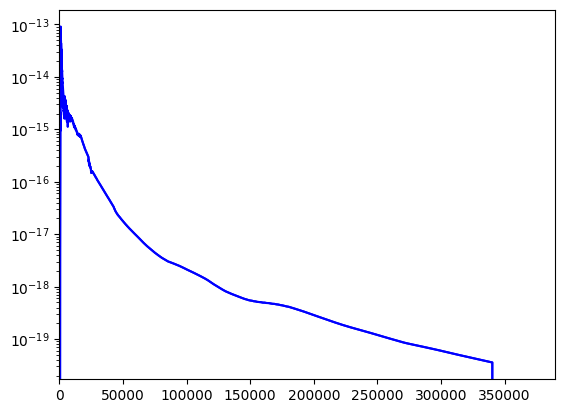

In [327]:
csp.add_sfh(sfr_bimodal, lookback_time=tau)
csp.add_zh(zh, lookback_time=tau)
emi_params = {'duste_qpah': 3.5, 
              'duste_umin': 1.0, 
              'duste_gamma': 0.01}
spec = csp.get_spectrum(dust_params=dust_params, emi_params=emi_params)
spec_dustfree = csp.get_spectrum_dustfree()

plt.plot(csp.wave, fnu2flam(csp.wave, spec*1e-23*3631), label='FSPS Dust-free', color='blue')
plt.plot(csp.wave, fnu2flam(csp.wave, spec_dustfree*1e-23*3631), label='FSPS Dust-free', color='blue')
plt.yscale('log')
plt.xlim(0, 390000)

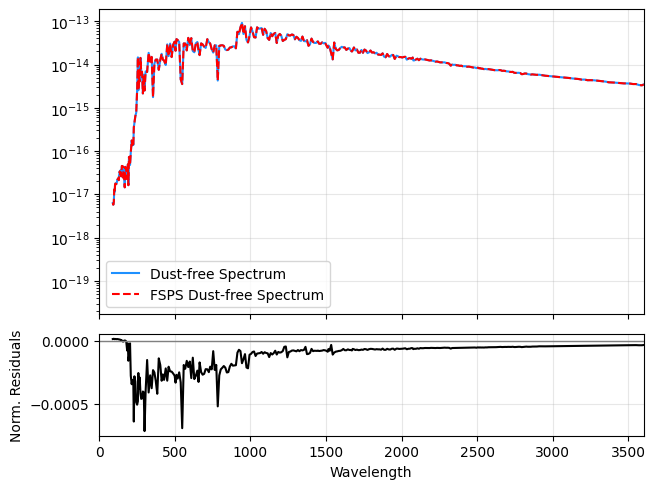

In [328]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20/3,5), gridspec_kw={'height_ratios':[3,1]}, sharex=True)
ax1.plot(csp.wave, fnu2flam(csp.wave, spec_dustfree*1e-23*3631), color = 'dodgerblue', label='Dust-free Spectrum')
ax1.plot(csp.wave, fnu2flam(csp.wave, spec_fsps_dustfree*1e-23*3631), '--', color = 'red', label='FSPS Dust-free Spectrum')
ax1.set_yscale('log'); ax1.set_xlim(0, 3600); ax1.legend(); ax1.grid(True, alpha=0.3)

resid = (fnu2flam(csp.wave, spec_dustfree*1e-23*3631) - fnu2flam(csp.wave, spec_fsps_dustfree*1e-23*3631))
resid /= fnu2flam(csp.wave, spec_fsps_dustfree*1e-23*3631)
ax2.plot(csp.wave, resid, 'k'); ax2.axhline(0, color='gray', lw=1)
ax2.set_xlabel('Wavelength'); ax2.set_ylabel('Norm. Residuals'); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [329]:
csp.diffuse

Array([2.8684656e+04, 2.5301373e+04, 2.3319684e+04, ..., 1.4457019e-15,
       1.4101305e-15, 1.3753762e-15], dtype=float32)

# Dust Attenuated Spectra

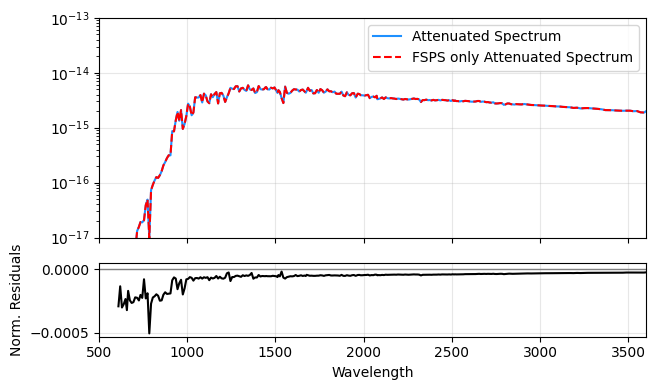

In [330]:
csp_attenuated = fnu2flam(csp.wave, spec*1e-23*3631)
fsps_attenuated = fnu2flam(csp.wave, spec_fsps_only_att*1e-23*3631) #fnu2flam(wave, spec_fsps_dustfree*jnp.exp(-csp.diffuse)*1e-23*3631)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20/3,4), gridspec_kw={'height_ratios':[3,1]}, sharex=True)
ax1.plot(csp.wave, csp_attenuated, color ='dodgerblue', label='Attenuated Spectrum')
ax1.plot(csp.wave, fsps_attenuated, '--', color = 'red', label='FSPS only Attenuated Spectrum')
ax1.set_yscale('log'); ax1.set_xlim(500, 3600); ax1.legend(); ax1.grid(True, alpha=0.3)

resid = (csp_attenuated - fsps_attenuated)
resid /= fsps_attenuated
ax2.plot(csp.wave, resid, color='k'); ax2.axhline(0, color='gray', lw=1)
ax2.set_xlabel('Wavelength'); ax2.set_ylabel('Norm. Residuals'); ax2.grid(True, alpha=0.3)
#ax1.set_ylim(10**-14.6, 10**-14.3)
ax1.set_ylim(10**-17, 10**-13)
plt.tight_layout()

In [331]:
fsps

<module 'fsps' from '/Users/amanda/opt/anaconda3/envs/phmc/lib/python3.10/site-packages/fsps/__init__.py'>

In [332]:
print('duste qpah:', sp.params['duste_qpah'])
print('duste umin:', sp.params['duste_umin'])
print('duste gamma:', sp.params['duste_gamma'])
print('add_agb_dust_model:', sp.params['agb_dust'])

duste qpah: 3.5
duste umin: 1.0
duste gamma: 0.01
add_agb_dust_model: 1.0


In [333]:
tiny_number = 1e-70

In [361]:
import jax.numpy as jnp
import jax

import numpy as np
from pathlib import Path

class DustEmission:

    def __init__(self, duste_model="DL07",
                 dust_file=None, spec_lambda=None, **kwargs):
        """
        Initialize the DustEmission object with parameters for dust emission modeling.

        Parameters
        ----------
        duste_model : str
            Dust emission model to use: 'DL07' or 'THEMIS'.
        dust_file : str
            Path to the dust emission file (required).
        spec_lambda : ndarray
            Wavelength grid over which dust emission will be evaluated (required).
        kwargs : dict
            Optional keyword arguments to override default dust parameters.
            Supported: duste_qpah, duste_umin, duste_gamma
        """

        # Store model choice (e.g., 'DL07' or 'THEMIS')
        self.duste_model = duste_model

        # Dust parameter values
        self.duste_qpah = None
        self.duste_umin = None
        self.duste_gamma = None

        # Model grid arrays for allowed values of qPAH and Umin
        self.qpaharr = None
        self.uminarr = None


        # Placeholder for loaded dust emission spectra
        self.dustem2_dustem = None

        # File path and wavelength grid
        self.dust_file = None
        self.spec_lambda = None

        # Store any additional keyword arguments for later use
        self.dwargs = kwargs

        # Read in key dust parameters, allowing overrides via kwargs
        self.duste_qpah = kwargs.pop("duste_qpah", 3.5)
        self.duste_umin = kwargs.pop("duste_umin", 1.0)
        self.duste_gamma = kwargs.pop("duste_gamma", 0.01)

        # Set parameter grids based on selected dust model
        if self.duste_model == "DL07":
            self.qpaharr = jnp.array([0.47,1.12,1.77,2.50,3.19,3.90,4.58])
            self.uminarr = jnp.array([
                0.1,0.15,0.2,0.3,0.4,0.5,0.7,0.8,1.0,1.2,1.5,2.0,
                2.5,3.0,4.0,5.0,7.0,8.0,12.0,15.0,20.0,25.0
            ])
        elif self.duste_model == "THEMIS":
            # THEMIS model uses smaller qPAH values rescaled to percent
            self.qpaharr = jnp.array([0.02, 0.06, 0.10, 0.14, 0.17, 0.20, 0.24,
                                      0.28, 0.32, 0.36, 0.40]) / 2.2 * 100
            self.uminarr = jnp.array([
                0.1, 0.12, 0.15, 0.17, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6,
                0.7, 0.8, 1.0, 1.2, 1.5, 1.7, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0,
                6.0, 7.0, 8.0, 10.0, 12.0, 15.0, 17.0, 20.0, 25.0, 30.0,
                35.0, 40.0, 50.0, 80.0
            ])
        else:
            raise ValueError("Invalid duste_model. Choose 'DL07' or 'THEMIS'.")

        # Ensure that necessary data is provided
        if dust_file is None or spec_lambda is None:
            raise ValueError("If `duste=True`, both `dust_file` and `spec_lambda` must be provided.")

        self.dust_file = dust_file
        self.spec_lambda = spec_lambda

        # Load emission templates or model data from file
        self.load_dust_emission(dust_file, spec_lambda)

    def __repr__(self):
        """
        Custom string representation of the DustEmission object.
        Provides a readable summary of model settings and parameters.
        """

        def format_array(arr):
            """Helper to format short arrays inline; longer arrays multiline."""
            if arr is None:
                return "None"
            if arr.ndim == 1 and len(arr) <= 5:
                return f"[{', '.join(map(str, arr))}]"
            return f"\n    " + "\n    ".join(map(str, arr))

        attributes = {
            "Duste model": self.duste_model,
            "DUST qPAH": self.duste_qpah,
            "DUST Umin": self.duste_umin,
            "DUST Gamma": self.duste_gamma,
            f"qpaharr ({self.duste_model})": format_array(self.qpaharr),
            f"uminarr ({self.duste_model})": format_array(self.uminarr),
            "dust_file": self.dust_file,
            "spec_lambda": self.spec_lambda.shape if self.spec_lambda is not None else None,
        }

        if self.dwargs:
            attributes["Extra parameters (dwargs)"] = self.dwargs

        attr_str = "\n".join(f"  {k:<30}: {v}" for k, v in attributes.items() if v is not None)
        return f"\nDustEmission Model:\n{'='*50}\n{attr_str}\n{'='*50}"


    def load_dust_emission(self, dust_file=None, spec_lambda=None):
        
        # Use default paths if not provided
        if dust_file is None:
            dust_file = self.dust_file
        if spec_lambda is None:
            spec_lambda = self.spec_lambda

        # Select dust model parameters
        dust_model_params = {
            "DL07": (7, 1001, 22),
            "THEMIS": (11, 576, 37),
        }
        
        if self.duste_model not in dust_model_params:
            raise ValueError("Invalid duste_model. Choose 'DL07' or 'THEMIS'.")

        nqpah_dustem, ndim_dustem, numin_dustem = dust_model_params[self.duste_model]

        # Initialize storage for interpolated spectra (JAX-compatible)
        dustem2_dustem = np.zeros((len(spec_lambda), nqpah_dustem, numin_dustem * 2))

        # Read and interpolate dust emission spectra
        for k in range(nqpah_dustem):
            filename = Path(dust_file) / "dust" / "dustem" / f"{self.duste_model}_MW3.1_{'100' if k == 10 else f'{k}0'}.dat"

            if not filename.exists():
                raise FileNotFoundError(f"Error opening dust emission file: {filename}. File does not exist.")

            with filename.open('r') as f:
                next(f)  # Skip first header line
                next(f)  # Skip second header line

                lambda_dustem = np.zeros(ndim_dustem)
                dustem_dustem = np.zeros((ndim_dustem, numin_dustem * 2))

                for i in range(ndim_dustem):
                    try:
                        values = list(map(float, f.readline().strip().split()))
                        lambda_dustem[i], dustem_dustem[i, :] = values[0], values[1:]
                    except Exception:
                        raise RuntimeError(f"Error reading dust emission file: {filename}")

            # Convert wavelength from microns to Angstroms
            lambda_dustem *= 1E4

            # Interpolate dust spectra onto the master wavelength array
            jj = jnp.searchsorted(spec_lambda / 1E4, 1, side='left')
            for j in range(numin_dustem * 2):
                dustem2_dustem[jj:, k, j] = jnp.interp(spec_lambda[jj:], lambda_dustem, dustem_dustem[:, j])

        self.dustem2_dustem = jnp.array(dustem2_dustem)

    def update_dust_params(self, duste_qpah = 3.5, duste_umin = 1.0, duste_gamma = 0.01):
        """
        Update dust parameters for emission calculations.

        Parameters:
            duste_qpah (float, optional): New PAH fraction.
            duste_umin (float, optional): New minimum U radiation field.
            duste_gamma (float, optional): New fraction of high U component.
        """
        self.duste_qpah = duste_qpah
        self.duste_umin = duste_umin
        self.duste_gamma = duste_gamma

    def compute_dust_emission(self, spec_attn, spec_dustfree, spec_lambda, diffuse_curve,
                                        duste_qpah=None, duste_umin=None, duste_gamma=None):
        """
        Compute dust emission using JAX-optimized vectorization for GPU acceleration.

        Parameters:
            spec_attn (jnp.ndarray): Attenuated spectrum after dust absorption.
            spec_dustfree (jnp.ndarray): Stellar spectrum before attenuation.
            spec_lambda (jnp.ndarray): Wavelength array in Angstroms.
            duste_qpah (float, optional): PAH fraction. Defaults to self.duste_qpah if None.
            duste_umin (float, optional): Minimum U radiation field. Defaults to self.duste_umin if None.
            duste_gamma (float, optional): Fraction of high U component. Defaults to self.duste_gamma if None.

        Returns:
            tuple: (Updated spectrum with dust emission added, Estimated dust mass)
        """

        # Use provided parameters if given, otherwise fallback to self attributes
        duste_qpah = self.duste_qpah
        duste_umin = self.duste_umin
        duste_gamma = self.duste_gamma

        def tsum(x, y):
            nn = len(x)
            tsum = jnp.sum(jnp.abs((x[1:nn] - x[0:nn-1])) * (y[1:nn] + y[0:nn-1]) / 2.0)
            return tsum

        # Compute total luminosity before and after attenuation
        nu = const.c / (spec_lambda * 1e-10)  # Frequency in Hz (c / λ)
        lbold = tsum(nu, spec_attn)#jnp.trapezoid(spec_attn, x=nu)
        lboln = tsum(nu, spec_dustfree)#jnp.trapezoid(spec_dustfree, x=nu)  # L_bol before attenuation
        # Interpolation indices for PAH fraction and Umin
        qlo = jnp.clip(jnp.searchsorted(self.qpaharr, duste_qpah) - 1, 0, len(self.qpaharr) - 2)
        dq = jnp.clip((duste_qpah - self.qpaharr[qlo]) / (self.qpaharr[qlo + 1] - self.qpaharr[qlo]), 0.0, 1.0)
        ulo = jnp.clip(jnp.searchsorted(self.uminarr, duste_umin) - 1, 0, len(self.uminarr) - 2)
        du = jnp.clip((duste_umin - self.uminarr[ulo]) / (self.uminarr[ulo + 1] - self.uminarr[ulo]), 0.0, 1.0)
    

        # Ensure gamma fraction is within [0,1]
        gamma = jnp.clip(duste_gamma, 0.0, 1.0)

        # Perform bilinear interpolation over qpah and Umin using `vmap`
        def interpolate_dustem(i):
            return (
                (1 - dq) * (1 - du) * self.dustem2_dustem[i, qlo, 2 * ulo - 1] +
                dq * (1 - du) * self.dustem2_dustem[i, qlo + 1, 2 * ulo - 1] +
                dq * du * self.dustem2_dustem[i, qlo + 1, 2 * (ulo + 1) - 1] +
                (1 - dq) * du * self.dustem2_dustem[i, qlo, 2 * (ulo + 1) - 1]
            ), (
                (1 - dq) * (1 - du) * self.dustem2_dustem[i, qlo, 2 * ulo] +
                dq * (1 - du) * self.dustem2_dustem[i, qlo + 1, 2 * ulo] +
                dq * du * self.dustem2_dustem[i, qlo + 1, 2 * (ulo + 1)] +
                (1 - dq) * du * self.dustem2_dustem[i, qlo, 2 * (ulo + 1)]
            )

        dumin, dumax = jax.vmap(interpolate_dustem)(jnp.arange(len(spec_lambda)))
        self.dumin = dumin
        self.dumax = dumax

        # Compute dust emission spectrum
        mduste = (1 - gamma) * dumin + gamma * dumax
        mduste = jnp.maximum(mduste, tiny_number)
        self.mduste = mduste
        # Normalize to absorbed luminosity
        labs =  lboln - lbold  # Energy absorbed by dust
        self.labs = labs
        norm = tsum(nu, mduste)  # Normalization factor
        self.norm = norm
        duste = jnp.maximum(mduste / norm * labs, tiny_number)  # Normalize dust emission

        #duste = jnp.maximum(duste, tiny_number)
        self.duste = duste
        tduste = jnp.zeros_like(duste)

        diff_dust = jnp.exp(-diffuse_curve)  # Apply diffuse dust attenuation

    
       
       # --- JAX while_loop implementation ---
        def body_fn(state):
            """
            The main loop body, which performs one iteration of dust self-absorption.
            All variables that change must be part of the state tuple.
            """
            duste, lboln_in, lbold_in, tduste_in, iself = state

            oduste = duste # old dust distribution (before absorption)
            duste_out = duste * diff_dust # Apply self-absorption attenuation
            tduste_out = tduste_in + duste_out

            # TSUM is an integration
            lbold_out = tsum(nu, duste_out)  # L_bol after self-absorption
            lboln_out = tsum(nu, oduste)  # L_bol before self-absorption

            # Recalculate duste for the next iteration
            duste_next = jnp.maximum(mduste / norm * (lboln_out - lbold_out), tiny_number)

            return (duste_next, lboln_out, lbold_out, tduste_out, 1)

        def cond_fn(state):
            """
            The loop condition function.
            FSPS: DO WHILE (((lboln-lbold).GT.1E-2).OR.iself.EQ.0)
            Means: run while difference > 1e-2 OR at least once
            """
            duste, lboln, lbold, tduste, iself = state
            return jnp.logical_or((lboln - lbold) > 1e-2, iself == 0)

        # Initial state for the loop (iself=0 to ensure at least one iteration)
        initial_state = (duste, lboln, lbold, tduste, 0)

        # Execute the while loop
        duste, _, _, _, _ = jax.lax.while_loop(cond_fn, body_fn, initial_state)



        # --- Final calculations after the loop ---
        # Compute estimated dust mass
        mdust = 3.21E-3 / (4 * jnp.pi) * labs / norm
        
        # Add dust emission to the stellar spectrum
        spec_duste = spec_attn + duste 
        
        return spec_attn, duste, mdust
    


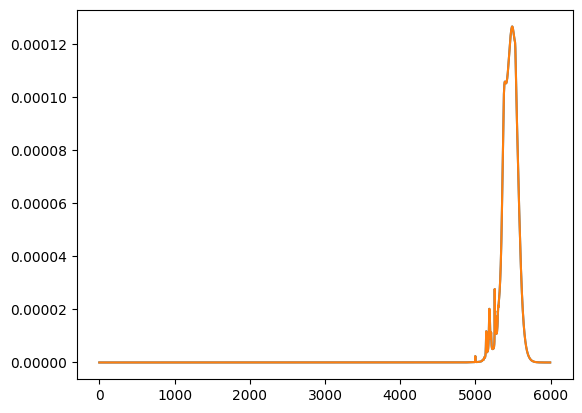

In [363]:
plt.plot(jnp.maximum(emi.mduste/emi.norm * emi.labs, tiny_number))
plt.plot(emi.duste)

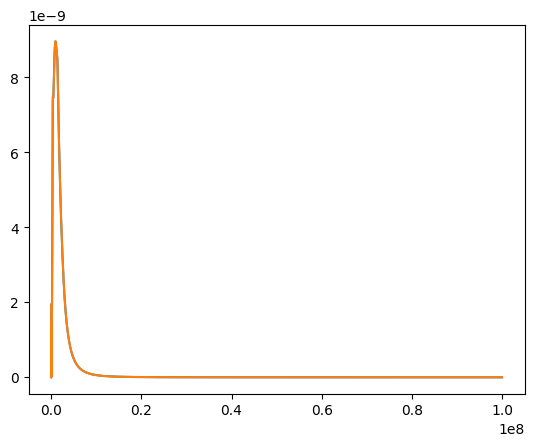

In [364]:
def tsum(x, y):
    nn = len(x)
    tsum = jnp.sum(jnp.abs((x[1:nn] - x[0:nn-1])) * (y[1:nn] + y[0:nn-1]) / 2.0)
    return tsum

tduste = jnp.zeros_like(emi.duste)

diff_dust = jnp.exp(-csp.diffuse)

oduste = emi.duste

duste_out = emi.duste * diff_dust
tduste_out = tduste * diff_dust
nu = const.c / (csp.wave * 1e-10) 
lbold_out = tsum(nu, duste_out)  # L_bol after self-absorption
lboln_out = tsum(nu, oduste)



#plt.plot(csp.wave, duste_out)
#plt.plot(csp.wave, tduste_out)


# Recalculate duste for the next iteration
duste_next = jnp.maximum(emi.mduste / emi.norm * (lboln_out - lbold_out), tiny_number)

duste_out_next = duste_next * diff_dust
tduste_out_next = tduste_out + duste_out_next
lbold_out_next = tsum(nu, duste_out_next)  # L_bol after self-absorption
lboln_out_next = tsum(nu, duste_next)  # L_bol before self-absorption
plt.plot(csp.wave, duste_out_next)
plt.plot(csp.wave, tduste_out_next)

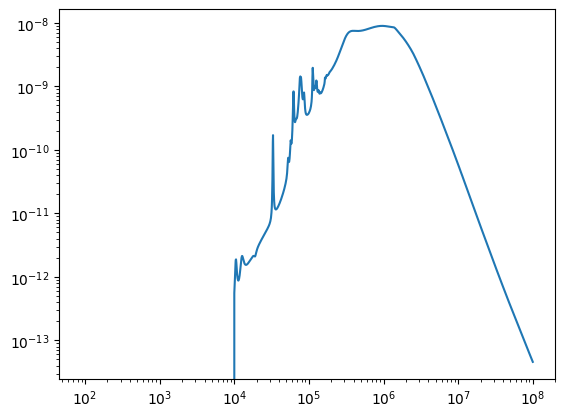

In [ ]:
plt.loglog(csp.wave, emi.mduste / emi.norm * (lboln_out - lbold_out))

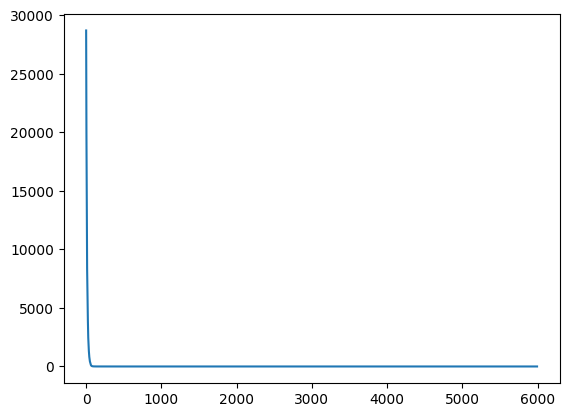

In [365]:
plt.plot(csp.diffuse)

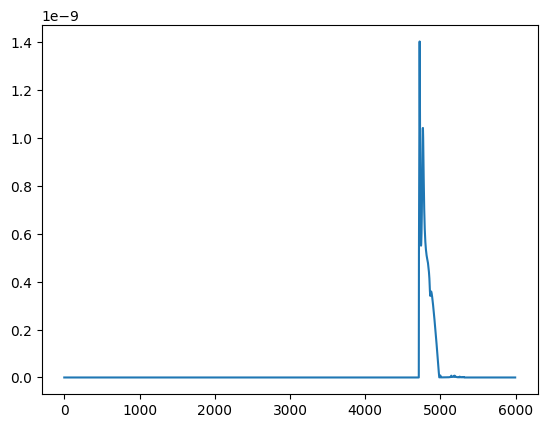

In [366]:
plt.plot(emi.duste - duste_out)

In [367]:

        )  # Apply diffuse dust attenuation

    
       
       # --- JAX while_loop implementation ---
        def body_fn(state):
            """
            The main loop body, which performs one iteration of dust self-absorption.
            All variables that change must be part of the state tuple.
            """
            duste, lboln_in, lbold_in, tduste_in, iself = state

            oduste = duste # old dust distribution (before absorption)
            duste_out = duste * diff_dust # Apply self-absorption attenuation
            tduste_out = tduste_in + duste_out

            # TSUM is an integration
            lbold_out = tsum(nu, duste_out)  # L_bol after self-absorption
            lboln_out = tsum(nu, oduste)  # L_bol before self-absorption

            # Recalculate duste for the next iteration
            duste_next = jnp.maximum(mduste / norm * (lboln_out - lbold_out), tiny_number)

            return (duste_next, lboln_out, lbold_out, tduste_out, 1)

        def cond_fn(state):
            """
            The loop condition function.
            FSPS: DO WHILE (((lboln-lbold).GT.1E-2).OR.iself.EQ.0)
            Means: run while difference > 1e-2 OR at least once
            """
            duste, lboln, lbold, tduste, iself = state
            return jnp.logical_or((lboln - lbold) > 1e-2, iself == 0)

        # Initial state for the loop (iself=0 to ensure at least one iteration)
        initial_state = (duste, lboln, lbold, tduste, 0)

        # Execute the while loop
        _, _, _, final_tduste, _ = jax.lax.while_loop(cond_fn, body_fn, initial_state)



SyntaxError: unmatched ')' (1202487625.py, line 1)

In [368]:
emi.labs

Array(1.5774659e+09, dtype=float32)

In [369]:
mdust_me - sp.dust_mass

Array(-10604265., dtype=float32)

In [370]:
from pathlib import Path

file_path = Path("/Users/amanda/Prospector/fsps/dust/dustem/DL07_MW3.1_20.dat")

with open(file_path, "r") as f:
    header_lines = [next(f).rstrip("\n") for _ in range(2)]

print("Header lines:")
for line in header_lines:
    print(line)

Header lines:
# lambda (um), Umin,min, Umin,max for Umin=0.10, 0.15,...25.0
# dust emission spectra are in units of Lnu (specifically, Jy cm2 sr-1 H-1); 3.3um PAH reduced by 50%


In [371]:
emi = DustEmission(spec_lambda=csp.wave, dust_file='/Users/amanda/Prospector/fsps')

emi.update_dust_params(duste_qpah=sp.params['duste_qpah'], duste_umin=sp.params['duste_umin'], duste_gamma=sp.params['duste_gamma'])
spec_attn, final_tduste, mdust = emi.compute_dust_emission(spec_attn = spec_fsps_only_att, spec_dustfree=spec_fsps_dustfree, spec_lambda=wave, diffuse_curve=csp.diffuse)

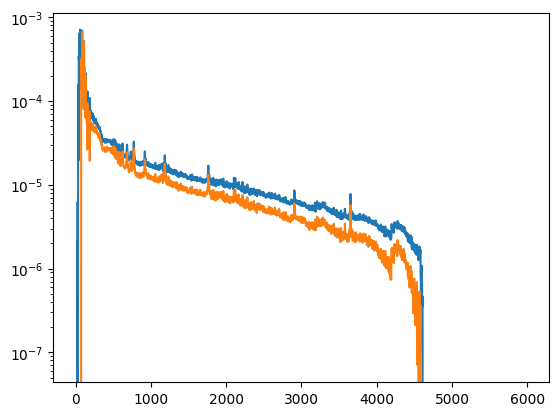

In [372]:
plt.plot((spec_fsps_dustfree - spec_dustfree)/spec_dustfree)
plt.plot((spec_fsps_only_att - spec)/spec)
plt.yscale('log')

# Add Dust Emission

/var/folders/vd/kv9mg1cx6tdfwmlfx2m5qfr80000gp/T/ipykernel_3961/4199942287.py:16: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(0, 5030000)


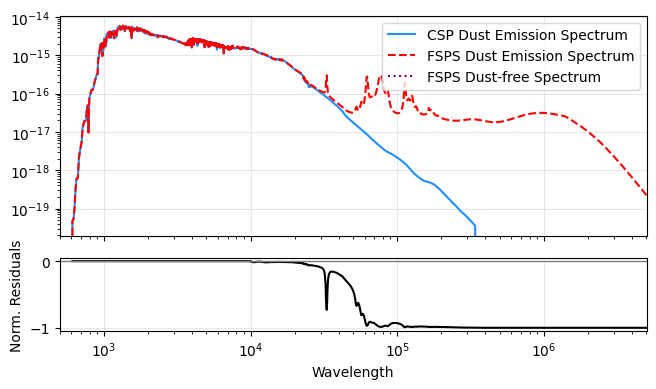

In [ ]:
csp_emi = fnu2flam(csp.wave, (spec_attn + final_tduste)*1e-23*3631)
fsps_emi = fnu2flam(csp.wave, spec_fsps*1e-23*3631) #fnu2flam(wave, spec_fsps_dustfree*jnp.exp(-csp.diffuse)*1e-23*3631)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20/3,4), gridspec_kw={'height_ratios':[3,1]}, sharex=True)
ax1.plot(csp.wave, csp_emi, color ='dodgerblue', label='CSP Dust Emission Spectrum')
ax1.plot(csp.wave, fsps_emi, '--', color = 'red', label='FSPS Dust Emission Spectrum')
ax1.plot(csp.wave, fnu2flam(csp.wave, emi.mduste*1e-23*3631), ':', color = 'purple', label='FSPS Dust-free Spectrum')

ax1.set_yscale('log');ax1.set_xscale('log'); ax1.set_xlim(500, 970000); ax1.legend(); ax1.grid(True, alpha=0.3)
resid = (csp_emi - fsps_emi)
resid /= fsps_emi
ax2.plot(csp.wave, resid, color='k'); ax2.axhline(0, color='gray', lw=1)
ax2.set_xlabel('Wavelength'); ax2.set_ylabel('Norm. Residuals'); ax2.grid(True, alpha=0.3)
ax1.set_xlim(0, 5030000)

#ax1.set_ylim(10**-17, 10**-13)
plt.tight_layout()

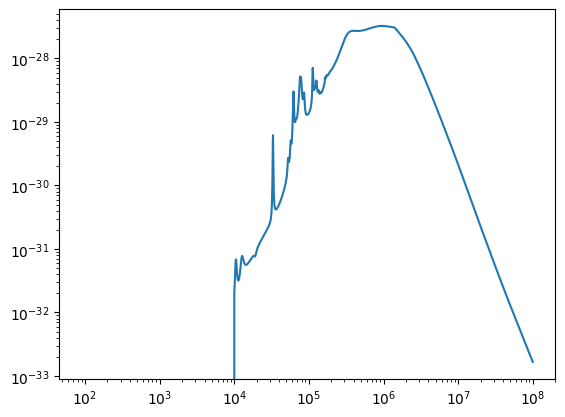

In [397]:
plt.loglog(csp.wave,(emi.mduste / emi.norm * (lboln_out - lbold_out))*1e-23*3631)

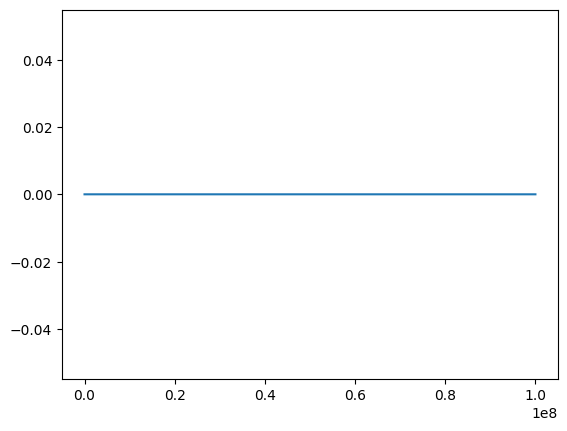

In [396]:
plt.plot(csp.wave, fnu2flam(csp.wave, (emi.mduste / emi.norm * (lboln_out - lbold_out))*1e-23*3631))

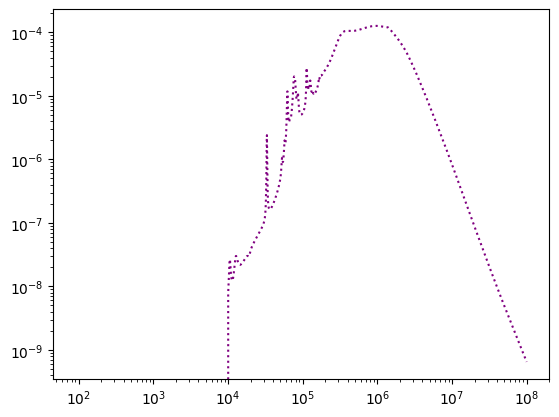

In [378]:
plt.loglog(csp.wave, emi.duste, ':', color = 'purple', label='FSPS Dust-free Spectrum')


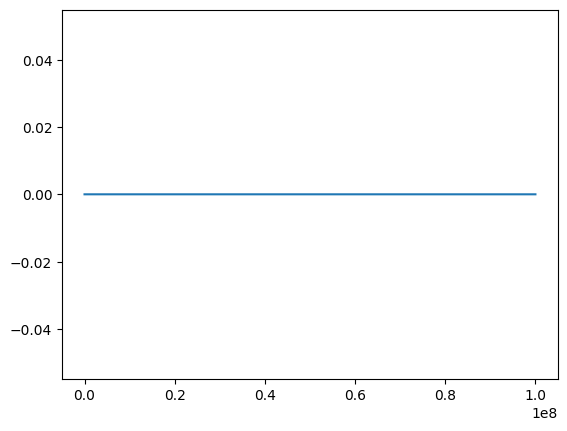

In [226]:
plt.plot(csp.wave, final_tduste)

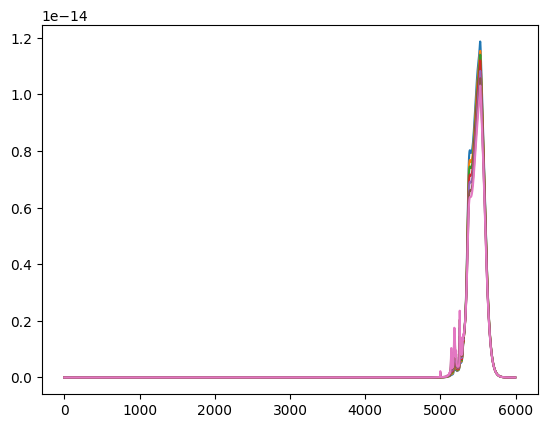

In [217]:
plt.plot(emi.dustem2_dustem[:, :, 5])

In [184]:
import pickle as pkl

fsps_path= Path('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/fsps_emi.pkl')
with fsps_path.open('wb') as f:
    pkl.dump(fsps_emi, f)

In [164]:
sp.params['nebemlineinspec']

False

In [92]:
with open('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/fsps_emi.pkl', 'rb') as f:
    fsps_emi = pkl.load(f)


In [93]:
fsps_emi

Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)